In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from extensible_sampling import ExtensibleSampling
import functions as f

import jax
from jax import random

# 1. $\mathcal{L}$ is linear.

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [ ]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)


ES = ExtensibleSampling(q_0,L,k)

In [3]:
T = 10
d = 2

x0 = jnp.ones(d) * 2
X_fin = ES.run_particles(x0,T)

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9


/var/folders/zl/0c18q_l567xgnm85cwp5t7xm0000gp/T/ipykernel_52892/1843275478.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')


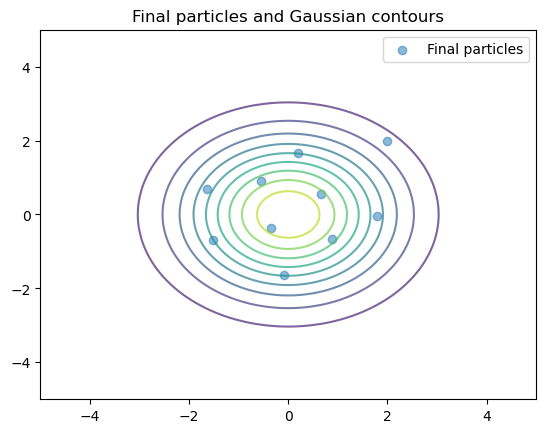

In [4]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax.scipy.stats import multivariate_normal

# Paramètres de la distribution
mean = jnp.zeros(2)  # Moyenne (0, 0)
cov = jnp.eye(2) * 2.0  # Matrice de covariance (2 * identité)

# Grille pour les lignes de niveau
x = jnp.linspace(-5, 5, 100)
y = jnp.linspace(-5, 5, 100)
X, Y = jnp.meshgrid(x, y)
pos = jnp.dstack((X, Y))

# Calcul de la densité de probabilité
Z = multivariate_normal.pdf(pos, mean, cov)

# Tracé
plt.scatter(X_fin[:, 0], X_fin[:, 1], alpha=0.5, label='Final particles')
plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.7, label='Gaussian contours')
plt.title("Final particles and Gaussian contours")
plt.legend()
plt.show()

In [5]:
X_fin

Array([[ 2.        ,  2.        ],
       [-0.35246226, -0.36625263],
       [-0.5521158 ,  0.8928852 ],
       [ 0.8877105 , -0.66150457],
       [-1.5209942 , -0.68329376],
       [ 0.66948324,  0.55522656],
       [-0.08987269, -1.6327298 ],
       [-1.6281648 ,  0.6893119 ],
       [ 1.7945886 , -0.05351067],
       [ 0.19412817,  1.6552145 ]], dtype=float32)

# Neural Network Learning
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from extensible_sampling import ExtensibleSampling
import jax_kernels as ker
import functions as f
import time

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random

In [6]:
device_name = "cpu"

In [ ]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(rng, input_dim, hidden_dim):
    rng1, rng2,rng3,rng4 = random.split(rng,4)
    params = {
        'W1': (random.uniform(rng1, (hidden_dim, input_dim))-0.5) * 10.0 ,
        'b1': random.normal(rng4, (hidden_dim,)),
        'W2': (random.uniform(rng2, (1, hidden_dim))- 0.5) * 10.0 ,
        'b2': random.normal(rng3, (1,)) 
    }
    return params

# 

@jit
def forward(params, z):
    h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
    y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
    return y.squeeze()


In [15]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(rng, input_dim, hidden_dim):
    rng1, rng2,rng3,rng4 = random.split(rng,4)
    params = {
        'W1': (random.uniform(rng1, (hidden_dim, input_dim))-0.5) * 10.0 ,
        'W2': (random.uniform(rng2, (1, hidden_dim))- 0.5) * 10.0 
    }
    return params

# 

@jit
def forward(params, z):
    h = jnp.tanh(jnp.dot(params['W1'], z))  # hidden layer
    y = jnp.dot(params['W2'], h)            # scalar output
    return y.squeeze()


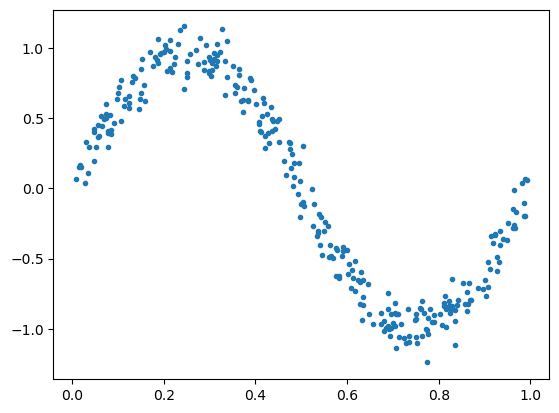

In [16]:

def generate_data(key, s, N, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]

    #explanation function
    def f(z):
        return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

N = 300
s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N, noise_std=0.1) # put more noise
device = jax.devices(device_name)[0]
Z, Y = jax.device_put((Z, Y), device)
plt.plot(Z,Y,".")

In [17]:
kernel_name = "IMQ"
c = jnp.array(1.0)
b = 3.0
def k(x,y):
    return (c**2 + (x-y).dot(x-y))**(-b)
    #return jnp.dot(x,y)

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*4)) #/ jnp.sqrt((2 * jnp.pi)**d)


key = random.PRNGKey(0)
hidden_dim = 1
params = init_params(key, s, hidden_dim)  
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)
#lambd = 0.1


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
    return E
gamma = 100
def L(X):  
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

k = jit(k)
q_0 = jit(q_0)
esp_forward = jit(esp_forward)
L = jit(L)  
 
ES = ExtensibleSampling(q_0,L,k)    

In [20]:
T = 100

key = random.PRNGKey(0)
param_0 = init_params(key, s, hidden_dim)
x0 = ravel_pytree(param_0)[0] 

X_fin = ES.run_particles(x0,T)

Iteration: 0
50
Iteration: 1
51
Iteration: 2
51
Iteration: 3
51
Iteration: 4
52
Iteration: 5
52
Iteration: 6
52
Iteration: 7
52
Iteration: 8
52
Iteration: 9
53
Iteration: 10
53
Iteration: 11
53
Iteration: 12
53
Iteration: 13
53
Iteration: 14
53
Iteration: 15
53
Iteration: 16
54
Iteration: 17
54
Iteration: 18
54
Iteration: 19
54
Iteration: 20
54
Iteration: 21
54
Iteration: 22
54
Iteration: 23
54
Iteration: 24
54
Iteration: 25
55
Iteration: 26
55
Iteration: 27
55
Iteration: 28
55
Iteration: 29
55
Iteration: 30
55
Iteration: 31
55
Iteration: 32
55
Iteration: 33
55
Iteration: 34
55
Iteration: 35
55
Iteration: 36
56
Iteration: 37
56
Iteration: 38
56
Iteration: 39
56
Iteration: 40
56
Iteration: 41
56
Iteration: 42
56
Iteration: 43
56
Iteration: 44
56
Iteration: 45
56
Iteration: 46
56
Iteration: 47
56
Iteration: 48
56
Iteration: 49
57
Iteration: 50
57
Iteration: 51
57
Iteration: 52
57
Iteration: 53
57
Iteration: 54
57
Iteration: 55
57
Iteration: 56
57
Iteration: 57
57
Iteration: 58
57
Iterati

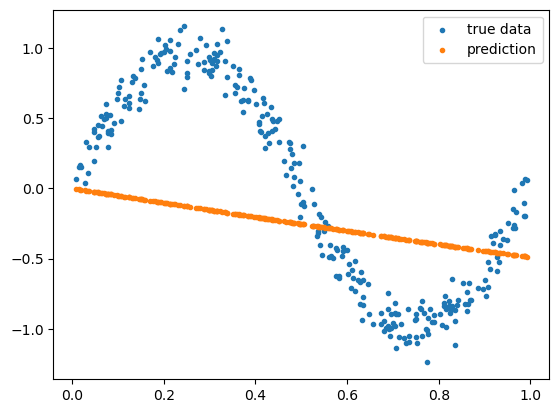

In [21]:
plt.figure()
plt.scatter(Z,Y,label = "true data",marker = ".")
Y_hat = vmap(lambda z : esp_forward(X_fin, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
plt.legend()
